In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

In [3]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison
from RVUtils.plt_timeseries import make_secondary_axis_plot

In [4]:
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")

tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(swaps_mdp),
    fixedratebonds_tb=FixedRateBondsTB(usts_mdp),
)

In [9]:
as_of = datetime.date(2023, 6, 2)
new_ref_df = (
    usts_mdp.get_bond_reference_data(as_of_date=as_of, kwargs={"append_free_float": True}).drop(columns=["record_date"]).rename(columns={"label": "ust_label"})
)
new_ref_df = new_ref_df[new_ref_df["ttm"] >= 1]

In [10]:
new_ref_df[new_ref_df["rank"] == 0]

,ust_label,cusip,rank,oi,auction_date,issue_date,maturity_date,ttm,cpn,outstanding_amt,portion_unstripped_amt,portion_stripped_amt,reconstituted_amt,soma_holdings,soma_holdings_of_pct_outstanding,outstanding_amt_backed_out_from_soma,free_float
90,T 3 5/8 May 53,912810TR9,0.0,30-Year,2023-05-11,2023-05-15,2053-05-15,29.950685,3.625,2.671122e+10,2.603481e+10,6.764162e+08,0.0,5.721292e+09,21.419058,2.671122e+10,2.031351e+10
91,T 3 7/8 May 43,912810TS7,0.0,20-Year,2023-05-17,2023-05-31,2043-05-15,19.950685,3.875,1.780598e+10,1.780598e+10,0.000000e+00,0.0,2.816959e+09,15.810548,1.781696e+10,1.498902e+10
328,T 3 5/8 May 26,91282CHB0,0.0,3-Year,2023-05-09,2023-05-15,2026-05-15,2.950685,3.625,5.088782e+10,5.088782e+10,0.000000e+00,0.0,1.089770e+10,21.415141,5.088782e+10,3.999012e+10
329,T 3 3/8 May 33,91282CHC8,0.0,10-Year,2023-05-10,2023-05-15,2033-05-15,9.950685,3.375,4.452506e+10,4.452468e+10,3.800000e+05,0.0,9.535486e+09,21.415998,4.452506e+10,3.498920e+10
330,T 4 1/4 May 25,91282CHD6,0.0,2-Year,2023-05-23,2023-05-31,2025-05-31,1.994521,4.250,4.988256e+10,4.988256e+10,0.000000e+00,0.0,7.887485e+09,15.810512,4.988760e+10,4.199508e+10
331,T 3 5/8 May 28,91282CHE4,0.0,5-Year,2023-05-24,2023-05-31,2028-05-31,4.996130,3.625,5.106016e+10,5.106016e+10,0.000000e+00,0.0,8.075282e+09,15.810543,5.107530e+10,4.298487e+10
332,T 3 3/4 May 30,91282CHF1,0.0,7-Year,2023-05-25,2023-05-31,2030-05-31,6.994521,3.750,4.156302e+10,4.156302e+10,0.000000e+00,0.0,6.572904e+09,15.810507,4.157301e+10,3.499011e+10


In [7]:
# cash ytms
new_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=new_ref_df["cusip"].to_list(), timestamp="live" if as_of == datetime.date.today() else as_of, show_tqdm=True)
)
new_ref_df["mdur"] = new_ref_df["cusip"].apply(lambda x: new_cusip_pricers[x].mod_duration() if x in new_cusip_pricers else np.nan)
new_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in new_cusip_pricers.items()])
new_market_df = pd.merge(left=new_market_df, right=new_ref_df, on="cusip")

new_cusips_to_fit = new_ref_df[(~new_ref_df["rank"].isin([0, 1, 2])) & (new_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()
# new_ttm = [new_cusip_pricers[cusip].time_to_maturity() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
# new_mod_dur = [new_cusip_pricers[cusip].mod_duration() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]
# new_ytm = [new_cusip_pricers[cusip].ytm() for cusip in new_cusips_to_fit if cusip in new_cusip_pricers]

# new_ytm_loess = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)
# new_ytm_bspline = GeneralCurveInterpolator(x=new_ttm, y=new_ytm).b_spline_with_|knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

new_ts_df = tb.get_timeseries(
    start=as_of,
    end=as_of,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in new_ref_df["cusip"]],
    n_jobs=5,
)

new_mmss_df = new_ts_df.T.copy().reset_index()
new_mmss_df.columns = ["query", "mmss"]
new_mmss_df["cusip"] = new_mmss_df["query"].str.split(" ", n=0).str[1]

new_mmss_df = pd.merge(left=new_mmss_df, right=new_ref_df, on="cusip")

new_clean_mmss_df = new_mmss_df[new_mmss_df["cusip"].isin(new_cusips_to_fit)].dropna(subset=["ttm", "mmss"]).sort_values(by="ttm")
new_mmss_bspline = GeneralCurveInterpolator(x=new_clean_mmss_df["ttm"], y=new_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
new_mmss_loess = GeneralCurveInterpolator(x=new_clean_mmss_df["ttm"], y=new_clean_mmss_df["mmss"]).loess_interpolation(frac=0.25, it=50, return_func=True)
# new_mmss_mdur_spline = GeneralCurveInterpolator(x=new_clean_mmss_df["mdur"], y=new_clean_mmss_df["mmss"]).loess_interpolation(frac=0.15, it=50, return_func=True)

PRICING FIXED-RATE BONDS.: 100%|██████████| 292/292 [00:00<00:00, 8552.57it/s]


In [9]:
compare = datetime.date(2025, 10, 1)

old_ref_df = (
    usts_mdp.get_bond_reference_data(as_of_date=compare, kwargs={"append_free_float": True}).drop(columns=["record_date"]).rename(columns={"label": "ust_label"})
)
old_ref_df = old_ref_df[old_ref_df["ttm"] >= 1]

# cash ytms
old_cusip_pricers = usts_mdp.get_pricer(
    request=dict(cusips=old_ref_df["cusip"].to_list(), timestamp="live" if compare == datetime.date.today() else compare, show_tqdm=True)
)
old_ref_df["mdur"] = old_ref_df["cusip"].apply(lambda x: old_cusip_pricers[x].mod_duration() if x in old_cusip_pricers else np.nan)
old_market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in old_cusip_pricers.items()])
old_market_df = pd.merge(left=old_market_df, right=old_ref_df, on="cusip")

old_cusips_to_fit = old_ref_df[(~old_ref_df["rank"].isin([0, 1, 2])) & (old_ref_df["free_float"] > 10_000_000_000)]["cusip"].to_list()
# old_ttm = [old_cusip_pricers[cusip].time_to_maturity() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]
# old_mod_dur = [old_cusip_pricers[cusip].mod_duration() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]
# old_ytm = [old_cusip_pricers[cusip].ytm() for cusip in old_cusips_to_fit if cusip in old_cusip_pricers]

# old_ytm_loess = GeneralCurveInterpolator(x=old_ttm, y=old_ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)
# old_ytm_bspline = GeneralCurveInterpolator(x=old_ttm, y=old_ytm).b_spline_with_knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

old_ts_df = tb.get_timeseries(
    start=compare,
    end=compare,
    queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor=c, value=IRSwapValue.MMSS) for c in old_ref_df["cusip"]],
    n_jobs=5,
)

old_mmss_df = old_ts_df.T.copy().reset_index()
old_mmss_df.columns = ["query", "mmss"]
old_mmss_df["cusip"] = old_mmss_df["query"].str.split(" ", n=0).str[1]

old_mmss_df = pd.merge(left=old_mmss_df, right=old_ref_df, on="cusip")

old_clean_mmss_df = old_mmss_df[old_mmss_df["cusip"].isin(old_cusips_to_fit)].dropna(subset=["ttm", "mmss"]).sort_values(by="ttm")
old_mmss_bspline = GeneralCurveInterpolator(x=old_clean_mmss_df["ttm"], y=old_clean_mmss_df["mmss"]).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=2, return_func=True
)
old_mmss_loess = GeneralCurveInterpolator(x=old_clean_mmss_df["ttm"], y=old_clean_mmss_df["mmss"]).loess_interpolation(frac=0.25, it=50, return_func=True)
# old_mmss_mdur_spline = GeneralCurveInterpolator(x=old_clean_mmss_df["mdur"], y=old_clean_mmss_df["mmss"]).loess_interpolation(frac=0.15, it=50, return_func=True)

FETCHING CUSIPS...: 100%|██████████| 291/291 [00:01<00:00, 285.39it/s]


In [126]:
# ctd_ref_df = usts_mdp.get_bond_reference_data(as_of_date=compare, kwargs={"cme_tcf": True})
# ctd_ref_df = ctd_ref_df[ctd_ref_df["period"] == 202512]
# # ctd_ref_df["dirty_price"] = ctd_ref_df["cusip"].apply(lambda x: usts_mdp._get_single_pricer(cusip=x, timestamp=compare).dirty_price()) 
# ctd_ref_df["clean_price"] = ctd_ref_df["cusip"].apply(lambda x: usts_mdp._get_single_pricer(cusip=x, timestamp=compare).clean_price()) 

# from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.stir_curve_building_utils import get_barchart_timeseries
# ustsf_df = get_barchart_timeseries(
#     tickers=["TUZ25", "FVZ25", "TYZ25", "UXYZ25", "USZ25", "WNZ25"],
#     start=compare,
#     end=compare,
#     interval=None,
#     use_globex=False,
# )
# ustsf_df.columns = [str(c)[:-3] for c in ustsf_df.columns]

# ctd_ref_df["futures_price"] = ctd_ref_df["ticker"].map(ustsf_df.to_dict("records")[0]) 
# ctd_ref_df["gross_basis"] = ctd_ref_df["clean_price"] - (ctd_ref_df["futures_price"] * ctd_ref_df["invoice_conversion_factor"])
# ctd_ref_df["gross_basis_32nds"] = (ctd_ref_df["gross_basis"] * 64).round() / 2
# # ctd_ref_df

# import rateslib as rl

# july32s = rl.FixedRateBond(
#     effective=rl.dt(2025, 7, 31),
#     termination=rl.dt(2032, 7, 31),
#     fixed_rate=4,
#     spec="us_gb",
#     curves="bcurve",
# )
# aug32s = rl.FixedRateBond(
#     effective=rl.dt(2025, 9, 2),
#     termination=rl.dt(2032, 7, 31),
#     fixed_rate=3.875,
#     spec="us_gb",
#     curves="bcurve",
# )

# usbf = rl.BondFuture(
# 	coupon=6.0,
# 	delivery=(rl.dt(2025, 12, 1), rl.dt(2025, 12, 29)),
# 	basket=[july32s, aug32s],
# 	calc_mode="ust_long",
# )
# rl_df = usbf.dlv(
#     future_price=113.46875,
#     prices=[101.40625, 100.62500],
#     repo_rate=4.18,
#     settlement=rl.dt(2025, 10, 24),
#     delivery=rl.dt(2025, 12, 29),
#     convention="act360",
# )
# rl_df["gross_basis_32nds"] = (rl_df["Gross Basis"] * 64).round() / 2
# rl_df


# def to_rl_dt(pydt: datetime.date):
# 	return rl.dt(pydt.year, pydt.month, pydt.day)

# def rl_ustf_basket(ctd_ref_df: pd.DataFrame, ust_mdp: FixedRateBondsMDP):
# 	prices = []
# 	basket = []
# 	timestamp = ctd_ref_df["as_of"].iloc[-1] 
# 	for _, row in ctd_ref_df.iterrows():
# 		pricer = ust_mdp.get_pricer(cusip=row["cusip"], timestamp=timestamp)[row["cusip"]]
# 		basket.append(
# 			rl.FixedRateBond(
# 				effective=to_rl_dt(pricer.issue_date()),
# 				termination=to_rl_dt(pricer.maturity_date()),
# 				fixed_rate=pricer.coupon(),
# 				spec="us_gb",
# 				curves="bcurve",
# 			)
# 		)
# 		prices.append(row["clean_price"])

# 	usbf = rl.BondFuture(
# 		coupon=6.0,
# 		delivery=(rl.dt(2025, 12, 1), rl.dt(2025, 12, 29)),
# 		basket=basket,
# 		calc_mode="ust_long",
# 	)
# 	return usbf.dlv(
# 		future_price=ctd_ref_df["futures_price"].iloc[-1],
# 		prices=prices,
# 		repo_rate=4.18,
# 		settlement=rl.dt(2025, 10, 24),
# 		delivery=rl.dt(2025, 12, 29),
# 		convention="act360",
# 	)



In [10]:
# plot_usts(
#     curve_set_df=new_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     cusips_hightlighter=[
#         ("912810UA4", "purple"),
#         ("912810UC0", "purple"),
#     ],
#     splines=[
#         (new_ytm_loess, "LOESS Spline"),
# 		(new_ytm_bspline, "BSpline", "red")
# 	],
#     title=f"Cash Treasuries Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
# )

# plot_usts(
#     # curve_set_df=mmss_df[
#     #     mmss_df["rank"].isin([0, 1, 2])
#     # ],
#     curve_set_df=new_mmss_df,
#     ttm_col="ttm",
#     ytm_col="mmss",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     cusips_hightlighter=[
#         ("912810UA4", "purple"),
#         ("912810UC0", "purple"),
#     ],
#     splines=[
#         # (mmss_mdur_spline, "LOESS Spline", "red"),
#         (new_mmss_bspline, "BSpline", "red")
#     ],
#     title=f"Cash Treasuries MMSS Complex: {next(iter(new_cusip_pricers.items()))[1].meta()["timestamp"]}",
#     # enable_hover_filters=True,
#     # numeric_bins=4,
# )
# display(new_mmss_df[new_mmss_df["rank"] == 0][["oi", "ust_label", "ttm", "mmss"]])


# fig, cmap = plot_usts_comparison(
#     curve_set_df=old_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=old_ref_df.columns.to_list(),
#     splines=[(old_ytm_bspline, "BSpline", "lightcoral")],
#     # title=f"Cash Treasuries Complex: {older} vs {newer}",
#     opacity=0.50,
#     name_suffix=str(compare),
#     show=False,
#     return_color_map=True,
# )
# fig = plot_usts_comparison(
#     curve_set_df=new_market_df,
#     ttm_col="ttm",
#     ytm_col="ytm",
#     label_col="oi",
#     cusip_col="cusip",
#     hover_data=new_ref_df.columns.to_list(),
#     splines=[(new_ytm_bspline, "BSpline", "red")],
#     title=f"Cash Treasuries Complex: {compare} vs {as_of}",
#     fig=fig,
#     opacity=1.0,
#     name_suffix=str(as_of),
#     color_discrete_map=cmap,
#     show=True,
# )

fig, cmap = plot_usts_comparison(
    curve_set_df=old_mmss_df,
    ttm_col="ttm",
    # ttm_col="mdur",
    ytm_col="mmss",
    label_col="oi",
    cusip_col="cusip",
    hover_data=old_ref_df.columns.to_list(),
    splines=[
        (old_mmss_bspline, "BSpline", "red")
        # (old_mmss_loess, "LOESS", "red")
        # (old_mmss_mdur_spline, "BSpline", "lightcoral")
    ],
    opacity=0.5,
    name_suffix=str(compare),
    show=False,
    return_color_map=True,
)
fig = plot_usts_comparison(
    curve_set_df=new_mmss_df,
    ttm_col="ttm",
    # ttm_col="mdur",
    ytm_col="mmss",
    label_col="oi",
    cusip_col="cusip",
    hover_data=new_ref_df.columns.to_list(),
    splines=[
        (new_mmss_bspline, "BSpline", "red")
        # (new_mmss_loess, "LOESS", "red")
        # (new_mmss_mdur_spline, "BSpline", "red")
    ],
    title=f"Cash Treasuries MMSS Complex: {compare} vs {as_of} | {new_cusip_pricers[new_ref_df[(new_ref_df["rank"] == 0) & (new_ref_df["oi"] == "10-Year")]["cusip"].iloc[-1]].meta()["timestamp"]}",
    fig=fig,
    opacity=1.0,
    name_suffix=str(as_of),
    color_discrete_map=cmap,
    show=True,
    cusips_hightlighter=[
        (_alias_to_cusip("0827-5", ref_table=new_ref_df), "pink"),
        # (_alias_to_cusip("0243-30", ref_table=new_ref_df), "pink"),
        # (_alias_to_cusip("1142-20", ref_table=new_ref_df), "pink"),
    ]
)


mmss_query = "rank == 0"
# mmss_query = "oi == '10-Year'"
# mmss_query = "ttm >= 7 and ttm < 10"
on = "oi"
# on = "cusip"
(
    new_mmss_df.query(mmss_query)[["oi", "cusip", "ust_label", "mmss", "ttm"]]
    .merge(
        old_mmss_df.query(mmss_query)[["oi", "cusip", "ust_label", "mmss", "ttm"]],
        on=on,
        suffixes=("_new", "_old"),
        how="inner",
    )
    .assign(chg_mmss_bps=lambda d: d["mmss_new"] - d["mmss_old"])
    .sort_values(by="ttm_new")
    .loc[:, [on, "ust_label_new", "ttm_new", "mmss_new", "chg_mmss_bps"]]
)

,oi,ust_label_new,ttm_new,mmss_new,chg_mmss_bps
3,2-Year,T 3 3/8 Nov 27,1.947945,-18.884609,2.871301
6,3-Year,T 3 1/2 Dec 28,2.989168,-21.594965,5.799152
5,5-Year,T 3 1/2 Nov 30,4.947945,-27.017891,7.880946
4,7-Year,T 3 3/4 Nov 32,6.948185,-33.748351,9.826324
2,10-Year,T 4 Nov 35,9.906849,-38.958351,10.993641
1,20-Year,T 4 5/8 Nov 45,19.906849,-64.644162,9.094130
0,30-Year,T 4 5/8 Nov 55,29.906849,-68.954220,10.610623


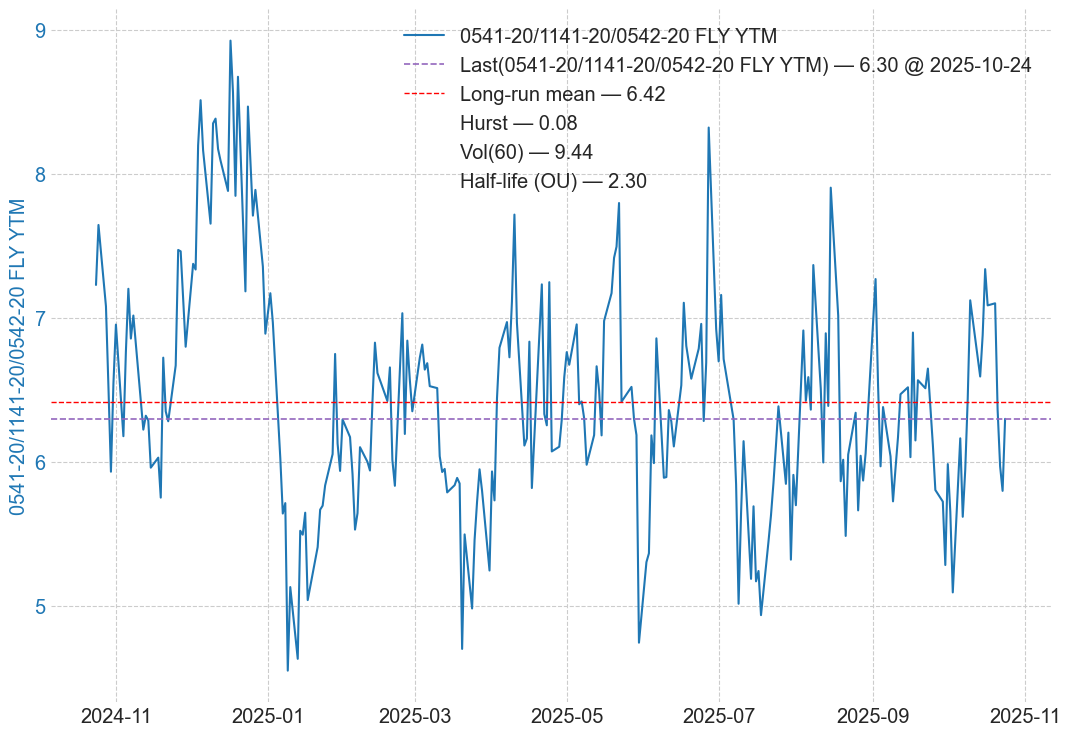

In [19]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

end = datetime.date(2025, 10, 24)
start = end - datetime.timedelta(days=365)
# start = datetime.date(2024, 1, 1)

# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS)
# q1 = IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER)
# q2 = FixedRateBondQuery(cusip="CT30", value=FixedRateBondValue.YTM)
# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="912810UA4/912810UC0", value=IRSwapValue.MMSS)
# q1 = FixedRateBondQuery(cusip="91282CBL4", value=FixedRateBondValue.YTM)
# q1 = FixedRateBondQuery(cusip="Ox5130/Ox5030", value=FixedRateBondValue.YTM)
# q2 = FixedRateBondQuery(cusip="1129-10/0530-10/0231-10", value=FixedRateBondValue.YTM)
q2 = FixedRateBondQuery(cusip="0541-20/1141-20/0542-20", value=FixedRateBondValue.YTM)
# q2 = IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # q,
        # q1,
        q2
    ],
    n_jobs=1,
)
	
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
plot(
    df[q2.col_name()],
    which="left",
    indicators=[
        {"kind": "last", "show_date": True, "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},
        # {"kind": "sma", "window": 20, "style": {"linestyle": "--", "color": "red"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "cum_change", "from_at": "2025-09-24", "label": "Chg from Logan TCGR Speech"},
        {"kind": "hurst", "hide": True},
        {"kind": "vol", "returns": "normal", "window": 60, "hide": True},
        {"kind": "half_life", "method": "ou", "demean": True, "style": {"linestyle": ":"}, "hide": True},
    ],
    # ou={"enable": True, "steps": 90, "add_metrics_to_legend": True}
)

# legend(show_date=True)
legend()
plt.show()

In [20]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
seasonality_df = monthend_cumsum_seasonality(df.dropna(), window=25)
display(seasonality_df)

fig = go.Figure()

# me_col = f"avg"
me_col = "avg-nov"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

# n_last = 12
# monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
# monthly_cols = sorted(monthly_cols)  # chronological
# keep = monthly_cols[-n_last:] if n_last > 0 else []

keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-25,0.129147,-1.47945,1.737744,-3.088047,3.346341,-0.953078,-1.967293,0.061138,-2.981508,1.075353,...,-2.242574,2.890956,2.090042,-0.299879,0.053986,-0.17455,-0.138067,-0.64106,-0.020027,0.0
-24,0.144056,-1.423867,1.711978,-2.99179,3.279901,-0.846767,-1.972288,0.278755,-3.09781,1.404276,...,-2.234013,2.916336,2.230041,-0.33135,0.039299,-0.068694,-0.288945,-0.304814,-0.280601,-0.296523
-23,0.109472,-1.419769,1.638712,-2.949009,3.167952,-0.727007,-1.59733,0.143316,-2.467653,1.013639,...,-1.563962,3.054421,2.295861,-0.08273,-0.171081,0.003594,-0.211525,-0.117493,-0.307586,0.090003
-22,0.096156,-1.251054,1.443366,-2.598264,2.790575,-0.449948,-1.231113,0.331216,-2.012277,1.112381,...,-1.477368,3.024292,2.236526,0.087885,-0.048439,0.013513,-0.38926,-0.531769,0.121307,0.050926
-21,0.120524,-1.134486,1.375535,-2.389497,2.630546,-0.12014,-0.77951,0.53923,-1.43888,1.1986,...,-0.734754,3.272436,-1.622612,-0.152028,-0.177904,0.100984,-0.404688,-0.499535,-0.032043,0.106621
-20,-0.039167,-1.331394,1.253061,-2.623621,2.545288,-0.037654,-0.701875,0.626567,-1.366097,1.290788,...,-0.475438,3.577042,-1.86366,0.022848,-0.212828,-0.13565,-0.138474,-0.270081,-0.291061,0.174553
-19,-0.131761,-1.484022,1.2205,-2.836283,2.572761,0.269036,-0.355907,0.893979,-0.980851,1.518922,...,-0.517209,3.484852,-1.688988,0.097846,-0.097611,-1.241904,-0.319672,-0.467873,-0.596428,0.107956
-18,-0.168176,-1.51135,1.174998,-2.854524,2.518172,0.122503,-0.415457,0.660463,-0.953417,1.198423,...,-0.809033,3.562148,-1.565964,-0.097318,-0.108212,-0.983649,-0.366783,-0.401115,-0.492555,-0.020218
-17,-0.167952,-1.493703,1.157798,-2.819453,2.483548,-0.045142,-0.438393,0.348109,-0.831643,0.74136,...,-0.648618,3.586388,-1.460869,-0.135465,-0.236312,-0.991304,-0.195694,-0.315285,-0.256348,0.326347
